In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N
aln.params.dt = .1

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

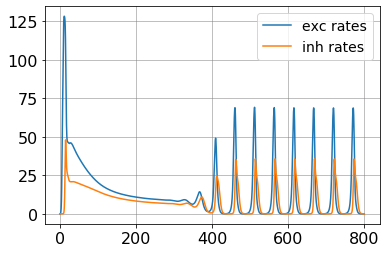

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

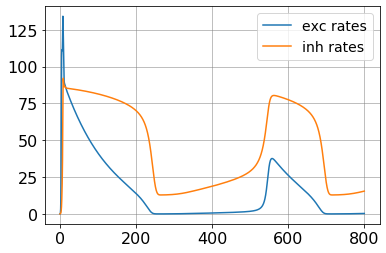

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

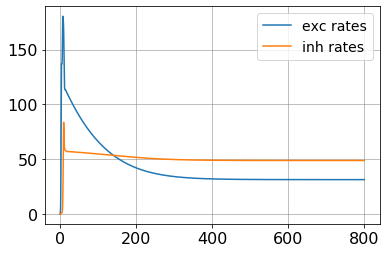

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

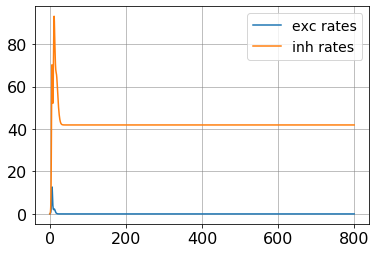

[4.4580e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

In [8]:
def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
    elif cntrl_vars == [1]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [2]:
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
            
    return max_cntrl, min_cntrl     

def findclosestindex(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate)):
        diff = np.abs(osc_rate[t] - stable_rate)
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind
        
    
def findclosestindex_2d(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate[0,:])):
        diff = np.abs(osc_rate[0,t] - stable_rate[0]) + np.abs(osc_rate[1,t] - stable_rate[1])
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind

def setpredur(prec_vars):
    if prec_vars == [0]:
        dur_pre = dur_pre_e
    elif prec_vars == [1]:
        dur_pre = dur_pre_i
    else:
        dur_pre = dur_pre_2d
    n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
    
    return dur_pre, n_pre

def settarget(initVars_, dur_, dur_pre_, n_pre_):
    aln.params.duration = dur_

    # set low state rates as target
    target = aln.getZeroTarget()
    target[:,0,n_dt_maxDelay:] = target_rates[0]
    target[:,1,n_dt_maxDelay:] = target_rates[1]

    aln.params.duration = dur_ + dur_pre_
    setinit(initVars_)
    aln.run(control=aln.getZeroControl())
    target[:,0,:n_dt_maxDelay] = aln.rates_exc[0,n_pre_:n_pre_+n_dt_maxDelay]
    target[:,1,:n_dt_maxDelay] = aln.rates_inh[0,n_pre_:n_pre_+n_dt_maxDelay]
    
    aln.params.duration = dur_
    
    return target

In [9]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 50
set_params_slow()
initVars = slow_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

sheet = "E_b_"

target_rates = np.array( [up_rates[0], up_rates[1]])

# 40 timesteps max delay
n_dt_maxDelay = aln.getMaxDelay()

In [10]:
dur = 700

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()

aln.run(control=control0)
mindiff_e, minind_e = findclosestindex(aln.rates_exc[0,:], target_rates[0], 2500)
print(mindiff_e, minind_e)
dur_pre_e = ( minind_e - n_dt_maxDelay ) / 10.
print(dur_pre_e)

mindiff_i, minind_i = findclosestindex(aln.rates_inh[0,:], target_rates[1], 2500)
print(mindiff_i, minind_i)
dur_pre_i = ( minind_i - n_dt_maxDelay ) / 10.
print(dur_pre_i)

findclosestindex_2d
mindiff_2d, minind_2d = findclosestindex_2d(np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] ),
                                            target_rates, 2500)
print(mindiff_2d, minind_2d)
dur_pre_2d = ( minind_2d - n_dt_maxDelay ) / 10.
print(dur_pre_2d)

0.011739605927605368 6833
679.3
0.0016107442272215167 6380
634.0
23.56542809275322 6380
634.0


## 0

set cost params
control input:  [0] , precision measure:  [0]
RUN  0 , total integrated cost =  76044.16171533606
RUN  1 , total integrated cost =  49229.951905394555
RUN  2 , total integrated cost =  49229.95190539454


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  49229.95190539454
Control only changes marginally.
RUN  3 , total integrated cost =  49229.95190539454
Improved over  3  iterations by  35.26136550800298  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -56.63334532408283 -56.63479992045119


'\nRUN  0 , total integrated cost =  120304.23529451675\nRUN  1 , total integrated cost =  120284.69388875752\nRUN  2 , total integrated cost =  120284.68487878371\n'

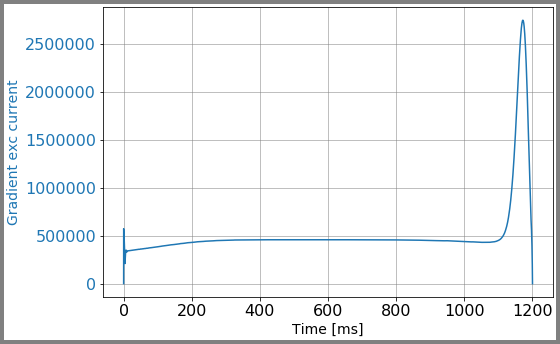

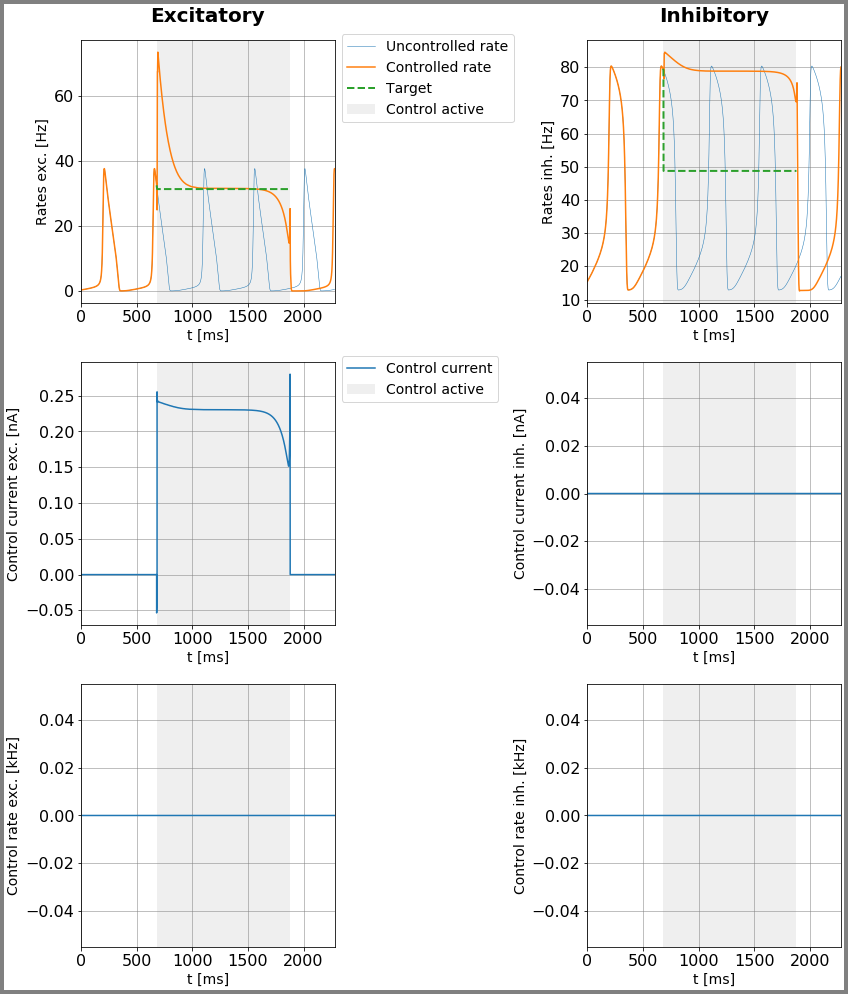

In [11]:
# C.0.a)

dur = 1200
dur_post = 400
n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

dur_pre, n_pre = setpredur(prec_vars)

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

control0 = aln.getZeroControl()

control0[0,0,n_dt_maxDelay:] = 1.4
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

"""
RUN  0 , total integrated cost =  120304.23529451675
RUN  1 , total integrated cost =  120284.69388875752
RUN  2 , total integrated cost =  120284.68487878371
"""

set cost params
RUN  0 , total integrated cost =  126490.50183784161
RUN  1 , total integrated cost =  114896.60032898714
RUN  2 , total integrated cost =  112813.0620369138
RUN  3 , total integrated cost =  112813.0620369133
RUN  4 , total integrated cost =  112813.06203691328


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  112813.06203691328
Control only changes marginally.
RUN  5 , total integrated cost =  112813.06203691328
Improved over  5  iterations by  10.813017263906929  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -73.82296988849613 -73.66085912476885


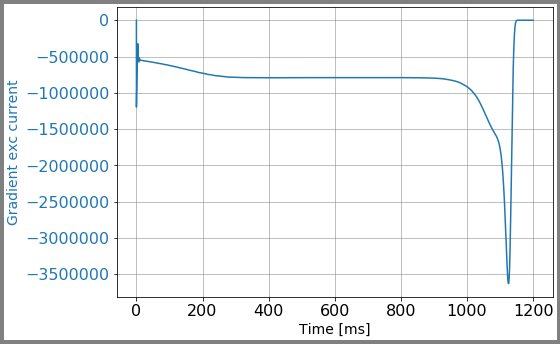

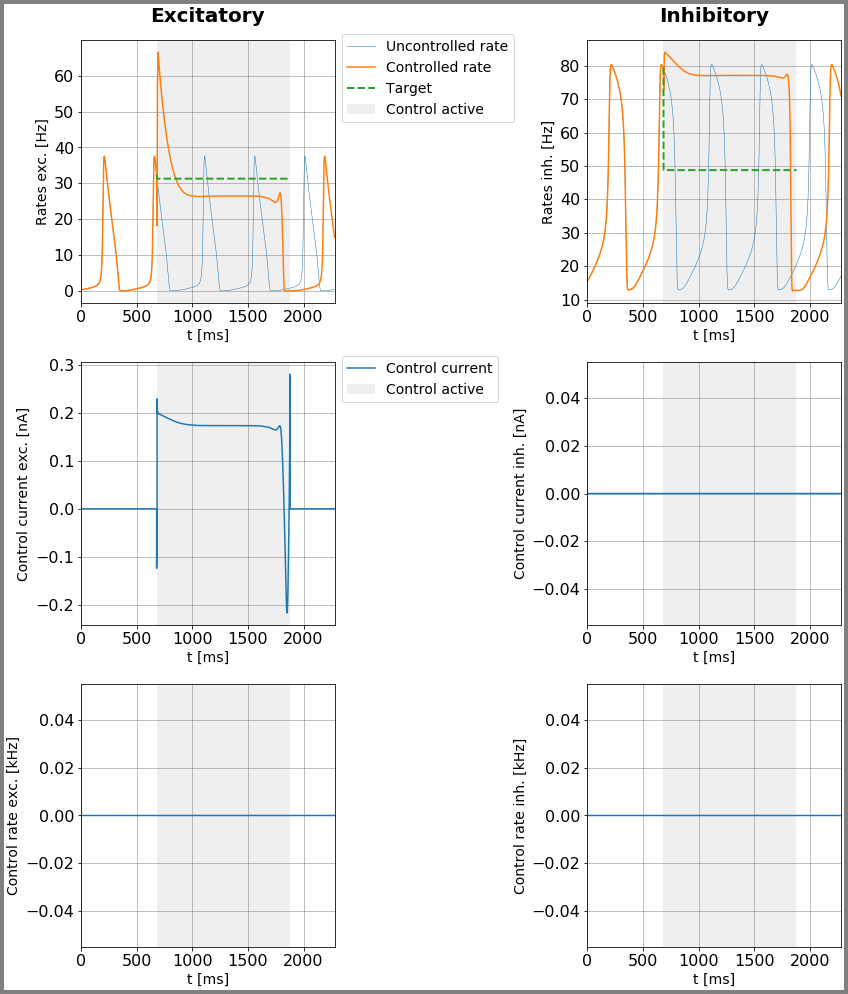

In [12]:

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 100.0, 10.0)

aln.params.duration = dur

control0 = aln.getZeroControl()
#control0[0,0,n_dt_maxDelay:] = -5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )


## 2

set cost params
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  109718.03704859078
RUN  1 , total integrated cost =  109718.03315103975


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  109718.03315103975
Control only changes marginally.
RUN  2 , total integrated cost =  109718.03315103975
Improved over  2  iterations by  3.552333907919092e-06  percent.
Problem in initial value trasfer:  sigmae_f 1.5021729762817624 1.5016424078624682
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.65554642705459
Problem in initial value trasfer:  sigmae_f 1.5018317534733188 1.5023322122584752
Problem in initial value trasfer:  Vmean_exc -56.64894991708307 -56.650632556898415
Problem in initial value trasfer:  tau_exc 3.7603884006981634 3.759939628454753


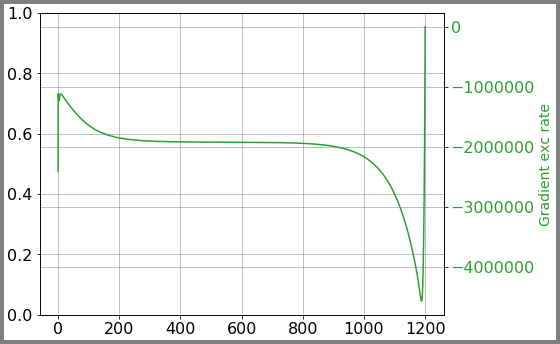

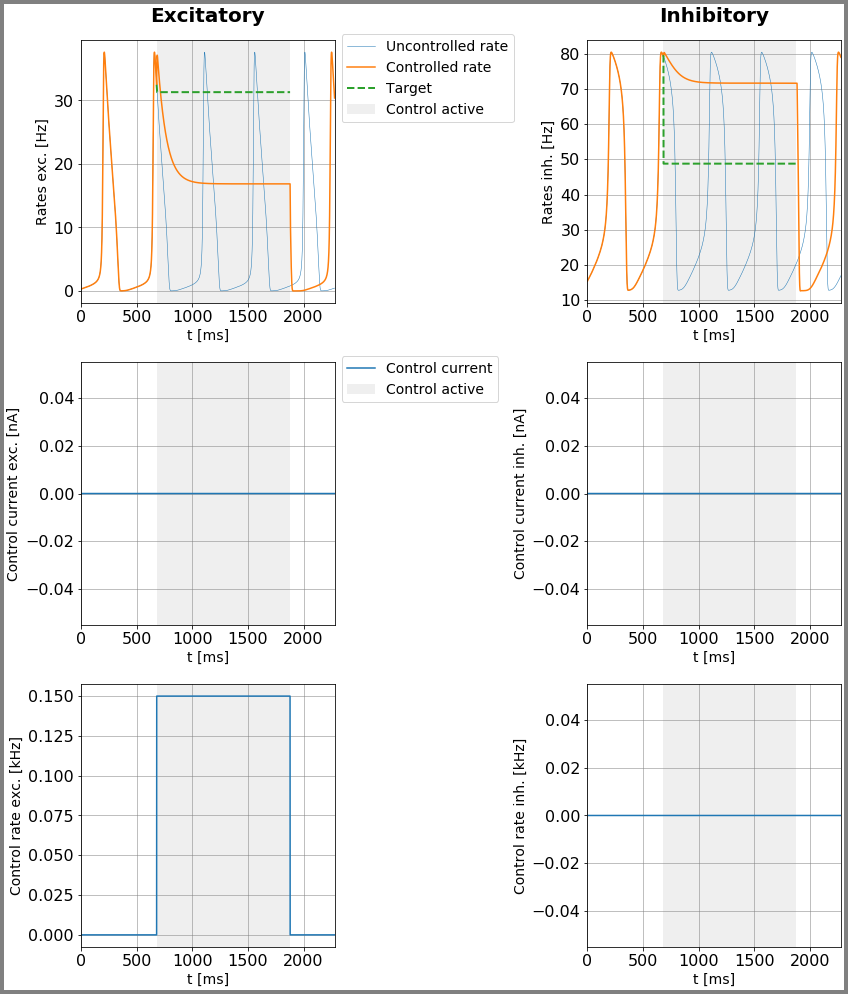

In [15]:
# A.0.a)

case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

control0 = aln.getZeroControl()
control0[:,2,:] = 0.15
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

max_it = 30

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl,  t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

# 67940

set cost params
RUN  0 , total integrated cost =  182420.03097313808
RUN  1 , total integrated cost =  182402.50254300088


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  182402.50254300088
Control only changes marginally.
RUN  2 , total integrated cost =  182402.50254300088
Improved over  2  iterations by  0.009608829712220768  percent.
Problem in initial value trasfer:  sigmae_f 1.5021729762817624 1.5016424078624682
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.65554642705459
Problem in initial value trasfer:  Vmean_exc -56.64894991708307 -56.650632556898415


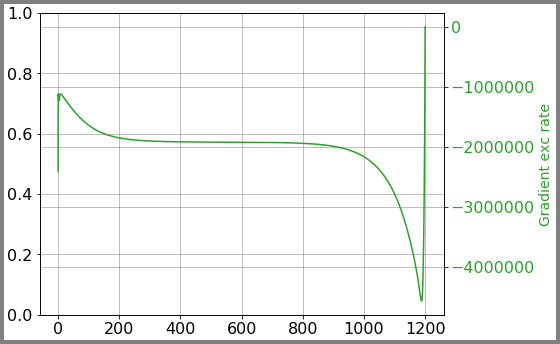

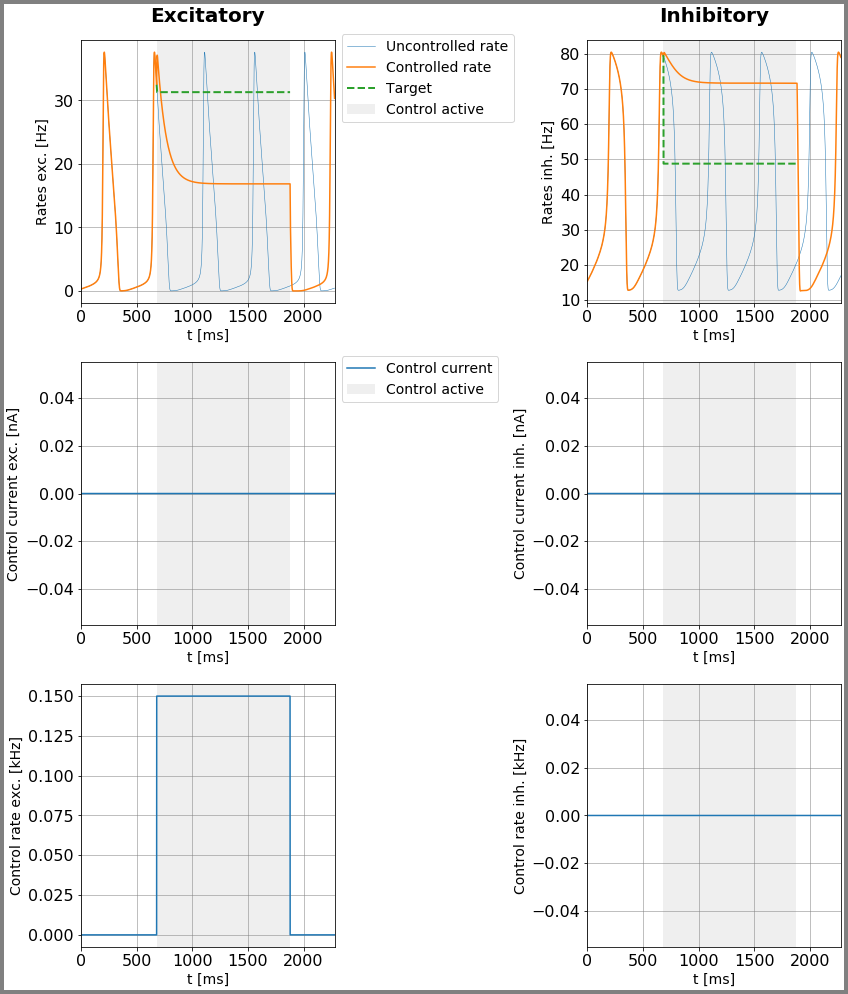

In [16]:

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 5000.0, 1000.0)

aln.params.duration = dur

ontrol0 = aln.getZeroControl()
control0[0,2,:] = 0.15
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 4

set cost params
control input:  [1] , precision measure:  [0]
RUN  0 , total integrated cost =  145126.06970308625
adj inh rate = [-7861.37218233 -8265.65718269 -8599.46408533 ...    -0.
    -0.            -0.        ]
adj mui = [-353503.00377156 -395260.91522312 -435104.14737454 ...       0.
       0.               0.        ]
RUN  1 , total integrated cost =  63932.45681939704
adj inh rate = [-3295.12053255 -3502.134915   -3673.82224657 ...    -0.
    -0.            -0.        ]
adj mui = [-216073.78357272 -246336.30636437 -275342.97548584 ...       0.
       0.               0.        ]
RUN  2 , total integrated cost =  60413.73790614531
adj inh rate = [-1817.17043689 -1936.54892002 -2035.47508153 ...    -0.
    -0.            -0.        ]
adj mui = [-132703.08231185 -151934.65501105 -170348.60761679 ...       0.
       0.               0.        ]
RUN  3 , total integrated cost =  59610.64856111989
adj inh rate = [-1057.71058627 -1128.63457896 -1187.43602988 ...    -0.
    -0.     

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  59456.853545339334
Improved over  22  iterations by  59.03089385181984  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -57.27922967208168 -57.320705534230044


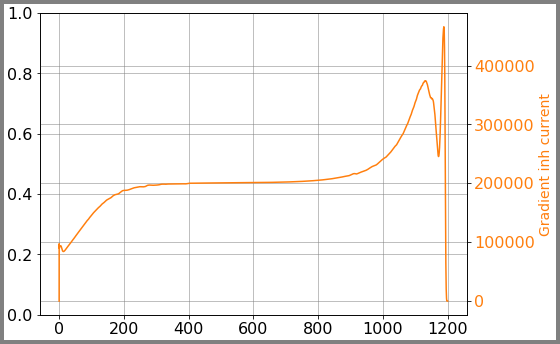

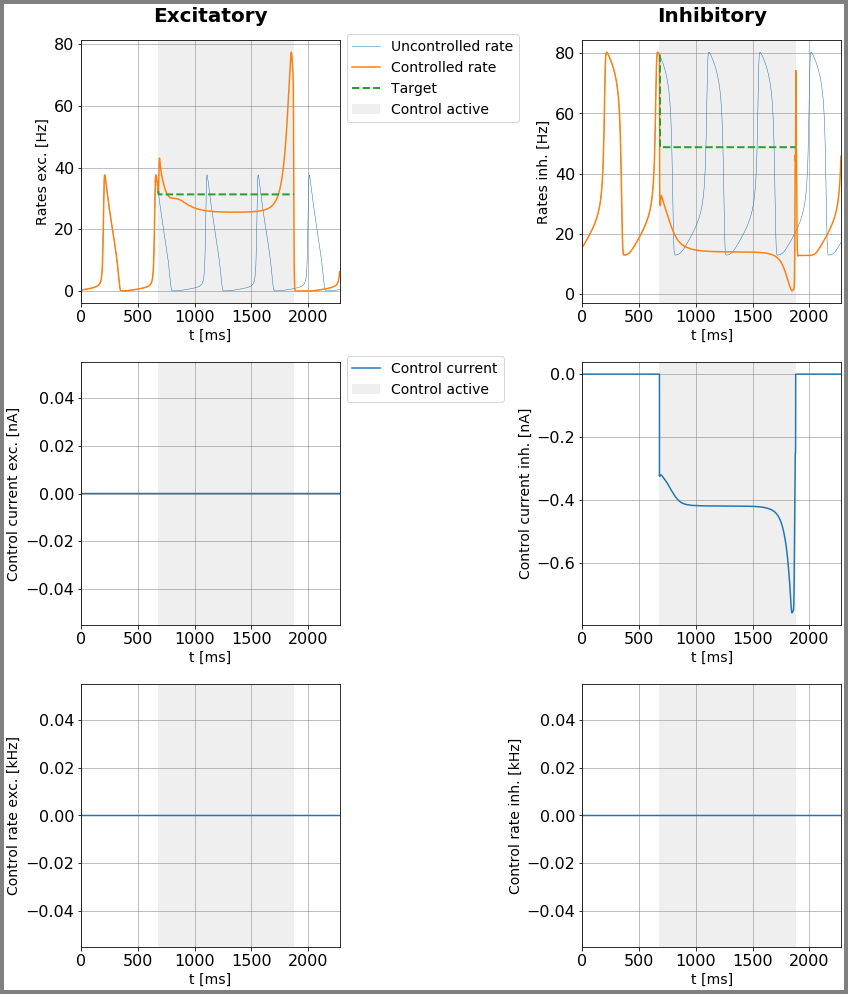

In [19]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

control0 = aln.getZeroControl()
control0[0,1,:] = -1.25
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  1485847.4587661733
adj inh rate = [-593.64714082 -633.95398955 -667.39485696 ...   -0.           -0.
   -0.        ]
adj mui = [-47555.22444242 -54625.7755264  -61395.9018739  ...      0.
      0.              0.        ]


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  1485847.4587661733
Control only changes marginally.
RUN  1 , total integrated cost =  1485847.4587661733
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -57.27922967208168 -57.320705534230044


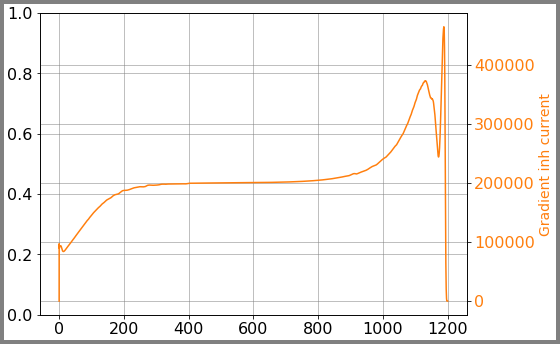

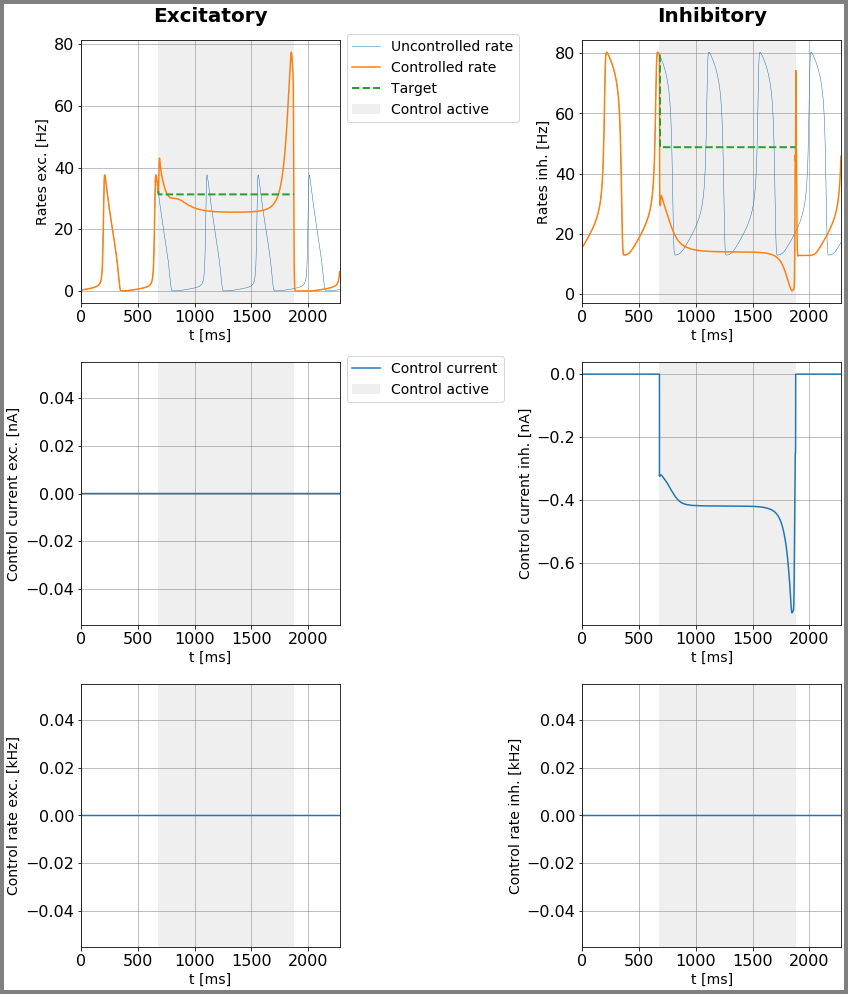

In [20]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 500.0, 100.0)

aln.params.duration = dur

control0 = aln.getZeroControl()
#control0[0,1,:] = -1.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
RUN  0 , total integrated cost =  417026.6660726161
adj inh rate = [9578.52433653 8171.026824   7058.68478903 ...   -0.           -0.
   -0.        ]
adj mui = [48657.20104653 32031.77767913 20292.57979285 ...     0.
     0.             0.        ]
RUN  1 , total integrated cost =  115089.37266976877
adj inh rate = [93.23644821 77.45142569 65.05419773 ... -0.         -0.
 -0.        ]
adj mui = [451.16993097 290.67559041 180.20105662 ...   0.           0.
   0.        ]
RUN  2 , total integrated cost =  115089.37266976871
adj inh rate = [93.23644821 77.45142569 65.05419773 ... -0.         -0.
 -0.        ]
adj mui = [451.16993097 290.67559041 180.20105662 ...   0.           0.
   0.        ]


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  115089.37266976871
Control only changes marginally.
RUN  3 , total integrated cost =  115089.37266976871
Improved over  3  iterations by  72.40239485075796  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -82.28500315423277 -82.04689907594877


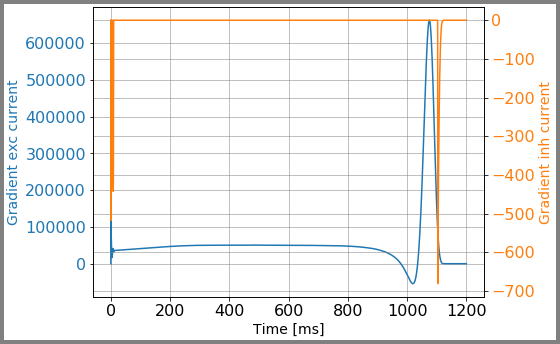

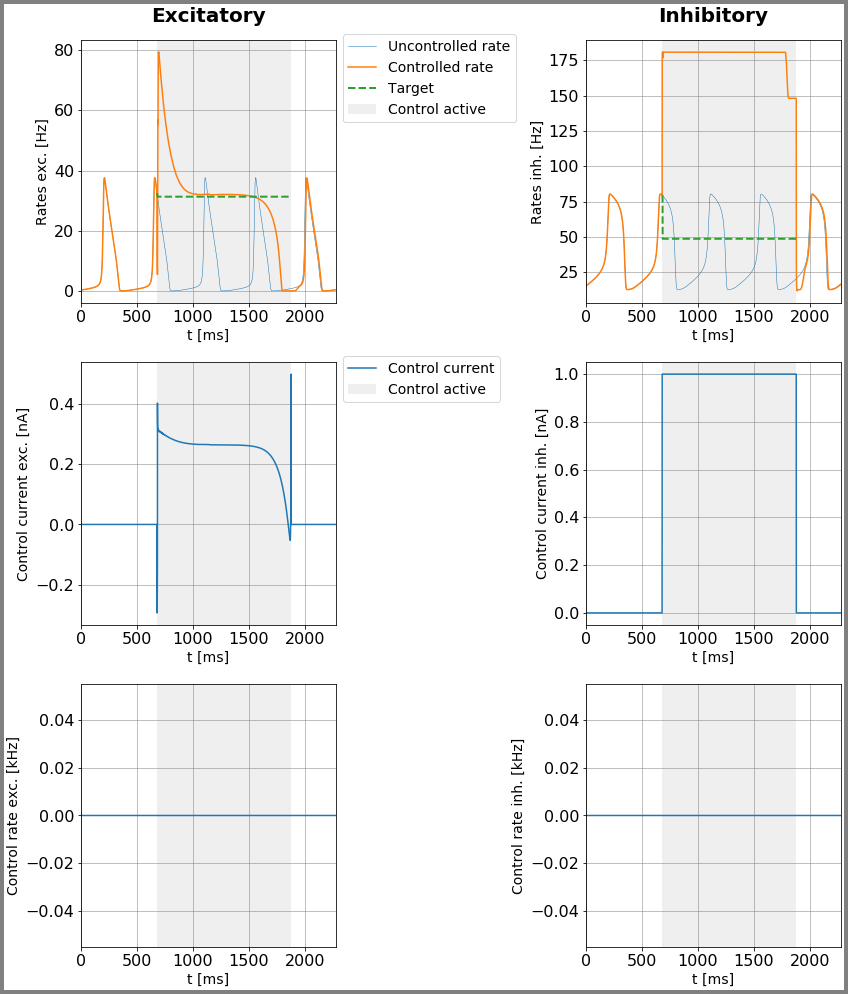

In [23]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = 2.5
control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

max_it = 30

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  594528.0977585248
adj inh rate = [12785.25734262 12451.37827192 12101.08171034 ...    -0.
    -0.            -0.        ]
adj mui = [176596.06186744 170722.96520417 164811.4729285  ...      0.
      0.              0.        ]
RUN  1 , total integrated cost =  136535.584698188
adj inh rate = [-1425.76035308 -1354.37113618 -1287.05582688 ...    -0.
    -0.            -0.        ]
adj mui = [-18454.90334826 -17652.63177645 -16914.39390022 ...      0.
      0.              0.        ]
RUN  2 , total integrated cost =  129219.56035891276
adj inh rate = [-1125.96009783 -1070.27370587 -1018.09860127 ...    -0.
    -0.            -0.        ]
adj mui = [-14729.0411718 -14122.2767423 -13558.582465  ...      0.
      0.             0.       ]
RUN  3 , total integrated cost =  126957.43813085345
adj inh rate = [-749.88219386 -711.71480289 -675.82372211 ...   -0.           -0.
   -0.        ]
adj mui = [-9734.83575607 -9318.41889413 -8932.14898553

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  126835.23801478985
Control only changes marginally.
RUN  10 , total integrated cost =  126835.23801478985
Improved over  10  iterations by  78.66623318679454  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -77.00159355357613 -76.70114513239658


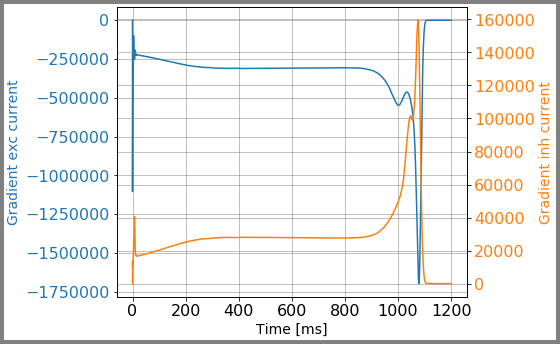

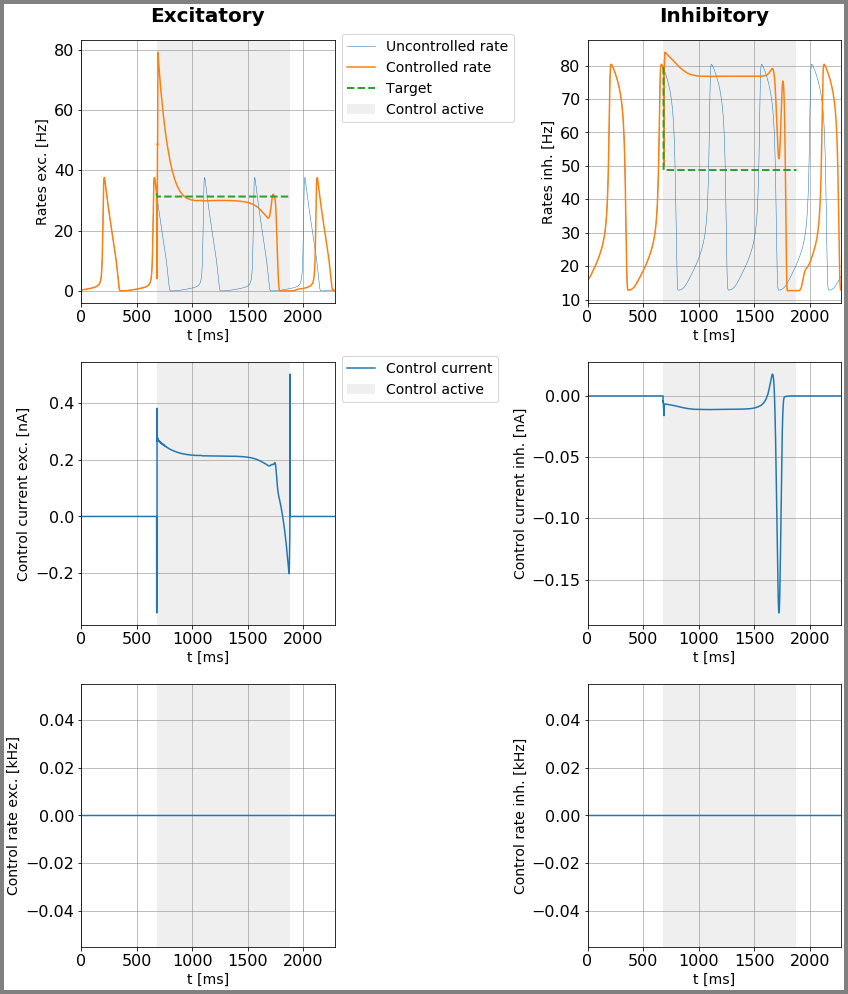

In [24]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = 2.5
#control0[0,1,:] = 1.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

#3813.6338429321895

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  486139.24316465505
adj inh rate = [10858.9584938  10860.34150771 10863.6000582  ...    -0.
    -0.            -0.        ]
adj mui = [177897.64756692 177948.86958068 177991.57957964 ...      0.
      0.              0.        ]
RUN  1 , total integrated cost =  117526.11497350936
adj inh rate = [-356.7024835  -356.90057709 -357.07723783 ...   -0.           -0.
   -0.        ]
adj mui = [-5829.18768336 -5827.18218766 -5823.8517347  ...     0.
     0.             0.        ]
RUN  2 , total integrated cost =  101875.26992859453
adj inh rate = [ 5.72367824e+55  5.35809217e+55  2.62254186e+55 ... -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00]
adj mui = [3.17151434e+56 1.95893376e+56 1.45351190e+56 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
 max iteration reached, step size =  2.718238677073099e-45
RUN  3 , total integrated cost =  100530.46815945045
adj inh rate = [ 3.86271072e+55  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  99258.78589683386
Control only changes marginally.
RUN  8 , total integrated cost =  99258.78589683386
Improved over  8  iterations by  79.58223136838699  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -56.88490424141435 -56.7879597800321


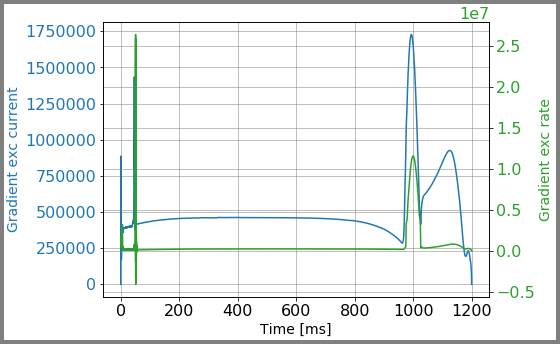

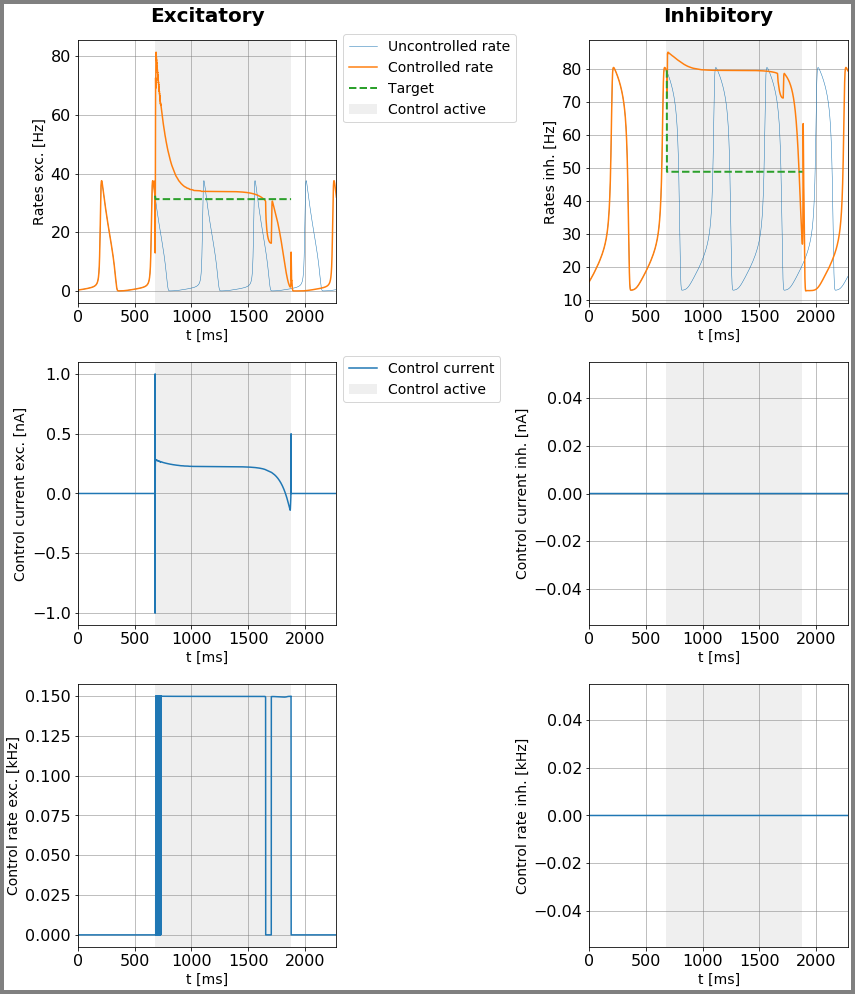

In [27]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

control0 = aln.getZeroControl()
control0[0,0,:] = 2.5
#control0[0,2,:] = 0.15
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  598908.4366108824
adj inh rate = [10858.9584938  10860.34150771 10863.6000582  ...    -0.
    -0.            -0.        ]
adj mui = [177897.64756692 177948.86958068 177991.57957964 ...      0.
      0.              0.        ]
RUN  1 , total integrated cost =  137643.60522932868
adj inh rate = [-1513.26506444 -1513.26570965 -1513.18966647 ...    -0.
    -0.            -0.        ]
adj mui = [-24714.65939243 -24705.89266265 -24694.3768824  ...      0.
      0.              0.        ]
RUN  2 , total integrated cost =  113942.05150558251
adj inh rate = [ 1.20747892e+41  1.13883079e+41  5.99119233e+40 ... -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00]
adj mui = [7.15744140e+41 4.67047763e+41 3.55816763e+41 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
 max iteration reached, step size =  2.718238677073099e-45
RUN  3 , total integrated cost =  112988.07126010823
adj inh rate = [ 6.21913228e+40  7.21169538e+40  8.34073342e+40 ... -0.

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  95732.14721542913
Control only changes marginally.
RUN  15 , total integrated cost =  95732.14721542913
Improved over  15  iterations by  84.01556208538979  percent.
Problem in initial value trasfer:  sigmae_f 1.5021729762817624 1.5016424078624682
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.65554642705459
Problem in initial value trasfer:  Vmean_exc -57.122208608704945 -56.967720017368194


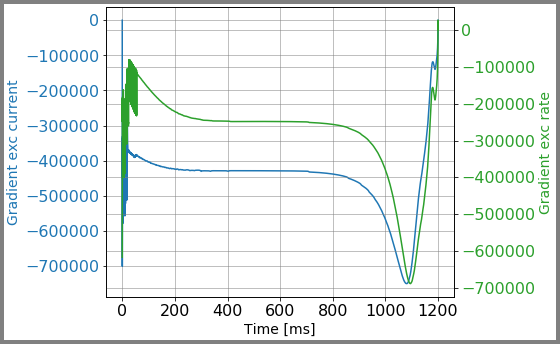

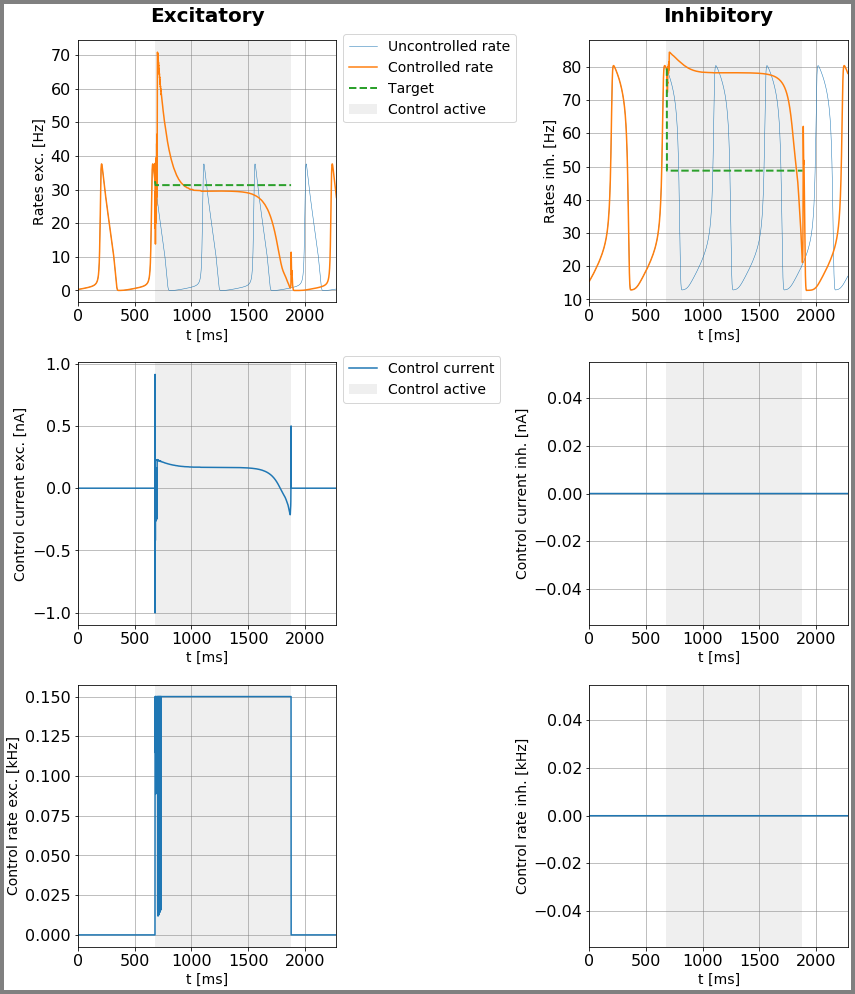

In [28]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

control0 = aln.getZeroControl()
control0[0,0,:] = 2.5
#control0[0,2,:] = 0.15
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  73146.78524150002
adj inh rate = [-5407.49496021 -5641.39836408 -5836.75088692 ...    -0.
    -0.            -0.        ]
adj mui = [-186073.122094   -204106.39000626 -221034.29661529 ...       0.
       0.               0.        ]
RUN  1 , total integrated cost =  24438.53371687152
adj inh rate = [-1448.68180589 -1552.70557264 -1640.7760818  ...    -0.
    -0.            -0.        ]
adj mui = [-122987.36980826 -141604.36883396 -159545.23495048 ...       0.
       0.               0.        ]
RUN  2 , total integrated cost =  24438.533716871512
adj inh rate = [-1448.68180589 -1552.70557264 -1640.7760818  ...    -0.
    -0.            -0.        ]
adj mui = [-122987.3698082  -141604.36883387 -159545.23495037 ...       0.
       0.               0.        ]


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  24438.533716871512
Control only changes marginally.
RUN  3 , total integrated cost =  24438.533716871512
Improved over  3  iterations by  66.58973646458185  percent.
Problem in initial value trasfer:  sigmae_f 1.5021729762817624 1.5016424078624682
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.65554642705459
Problem in initial value trasfer:  sigmae_f 1.5049808948998444 1.505021033181639
Problem in initial value trasfer:  Vmean_exc -56.62878073685604 -56.63003143817435
Problem in initial value trasfer:  tau_exc 3.1134970884576973 3.113480230379344


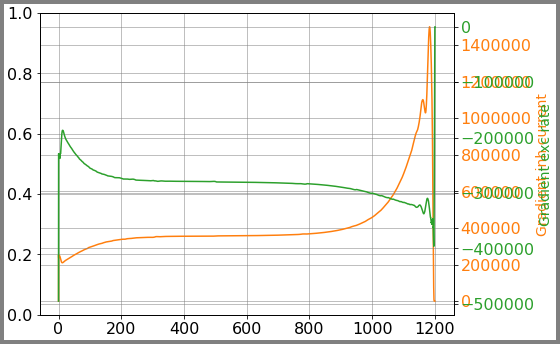

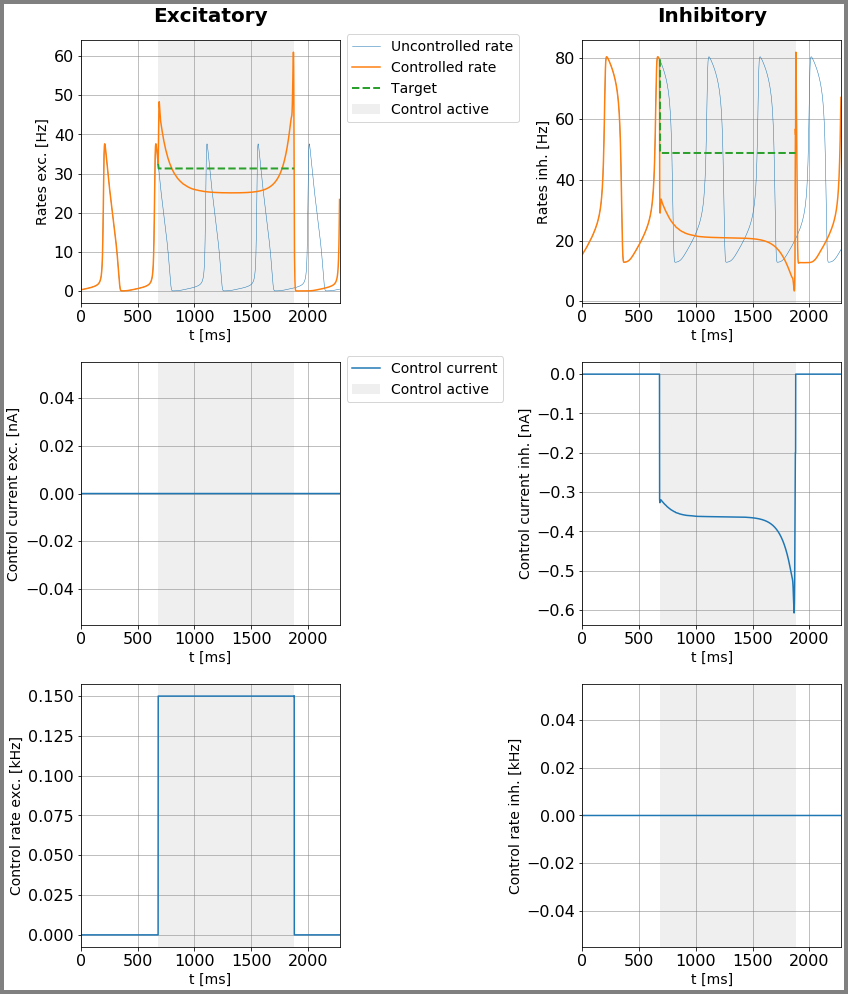

In [31]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

control0 = aln.getZeroControl()
control0[0,1,:] = -1.
control0[0,2,:] = 0.15
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

max_it = 30

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  134900.2860257283
adj inh rate = [-5407.49496021 -5641.39836408 -5836.75088692 ...    -0.
    -0.            -0.        ]
adj mui = [-186073.122094   -204106.39000626 -221034.29661529 ...       0.
       0.               0.        ]
RUN  1 , total integrated cost =  134900.28602572385
adj inh rate = [-5407.49496024 -5641.39836411 -5836.75088696 ...    -0.
    -0.            -0.        ]
adj mui = [-186073.12209591 -204106.39000845 -221034.29661822 ...       0.
       0.               0.        ]
RUN  2 , total integrated cost =  134900.28602572376
adj inh rate = [-5407.49496023 -5641.39836409 -5836.75088694 ...    -0.
    -0.            -0.        ]
adj mui = [-186073.122096   -204106.39000861 -221034.29661756 ...       0.
       0.               0.        ]
RUN  3 , total integrated cost =  134900.28602572373
adj inh rate = [-5407.49496023 -5641.3983641  -5836.75088694 ...    -0.
    -0.            -0.        ]
adj mui = [-186073.12209

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  134900.28602572373
Control only changes marginally.
RUN  4 , total integrated cost =  134900.28602572373
Improved over  4  iterations by  3.382183422218077e-12  percent.
Problem in initial value trasfer:  sigmae_f 1.5021729762817624 1.5016424078624682
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.65554642705459
Problem in initial value trasfer:  sigmae_f 1.50599109202519 1.5063088127037596
Problem in initial value trasfer:  Vmean_exc -56.63534038735933 -56.63603219038619
Problem in initial value trasfer:  tau_exc 3.235252835679772 3.2350979382871357


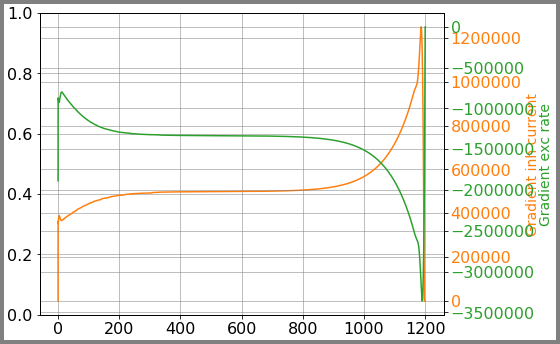

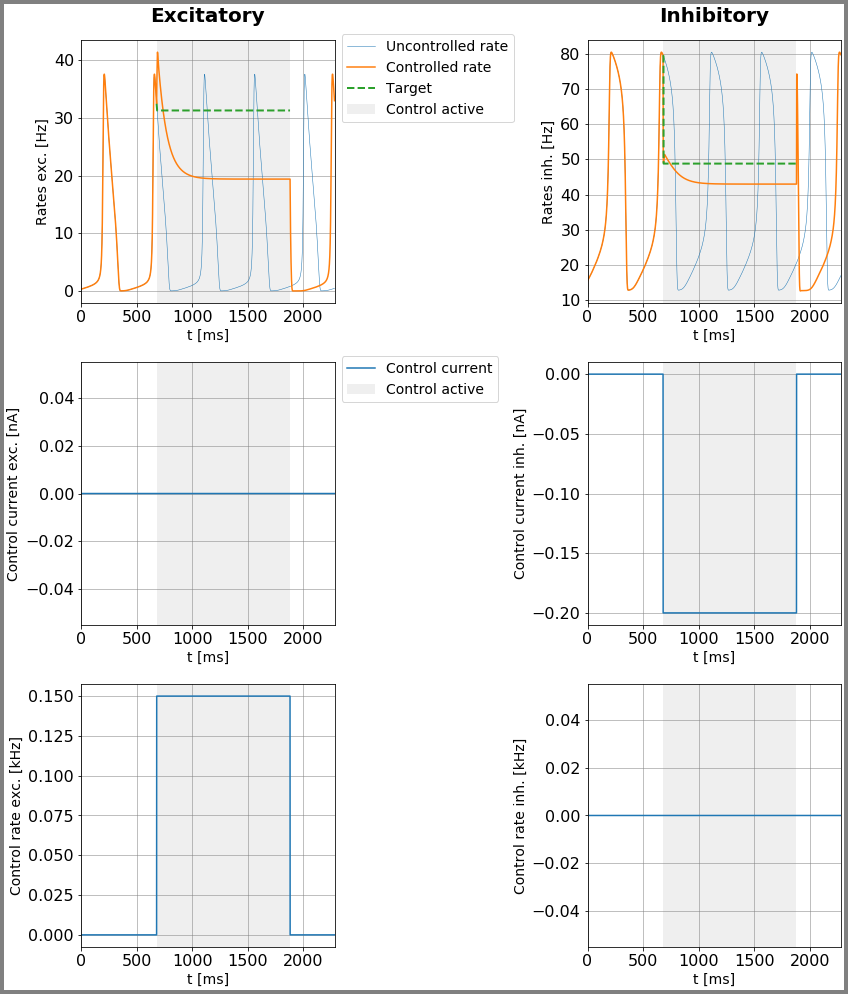

In [32]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 100.0, 10.0)

aln.params.duration = dur

control0 = aln.getZeroControl()
control0[0,1,:] = -1.
control0[0,2,:] = 0.15
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  76044.16171533606
adj inh rate = [3804.86361611 3729.2505325  3649.76280498 ...   -0.           -0.
   -0.        ]
adj mui = [54789.99820219 53442.54890884 52082.52406202 ...     0.
     0.             0.        ]
RUN  1 , total integrated cost =  41751.02025903516
adj inh rate = [551.40494836 470.78719652 407.25555335 ...  -0.          -0.
  -0.        ]
adj mui = [2807.52181105 1850.79446957 1174.85294691 ...    0.            0.
    0.        ]
RUN  2 , total integrated cost =  41751.02025903513
adj inh rate = [551.40494836 470.78719652 407.25555335 ...  -0.          -0.
  -0.        ]
adj mui = [2807.52181105 1850.79446957 1174.85294691 ...    0.            0.
    0.        ]
RUN  3 , total integrated cost =  41751.020259035125
adj inh rate = [551.40494836 470.78719652 407.25555335 ...  -0.          -0.
  -0.        ]
adj mui = [2807.52181105 1850.79446957 1174.85294691 ...    0.  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  41751.020259035125
Control only changes marginally.
RUN  4 , total integrated cost =  41751.020259035125
Improved over  4  iterations by  45.09635017698529  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -56.63075024517707 -56.63197158335137


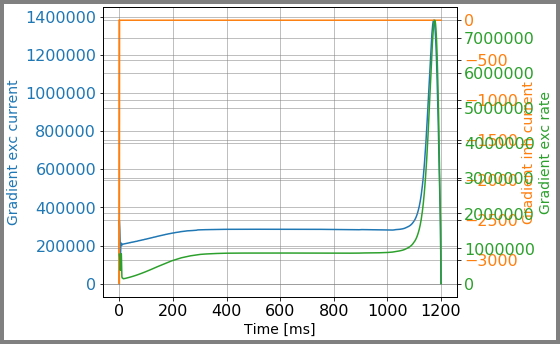

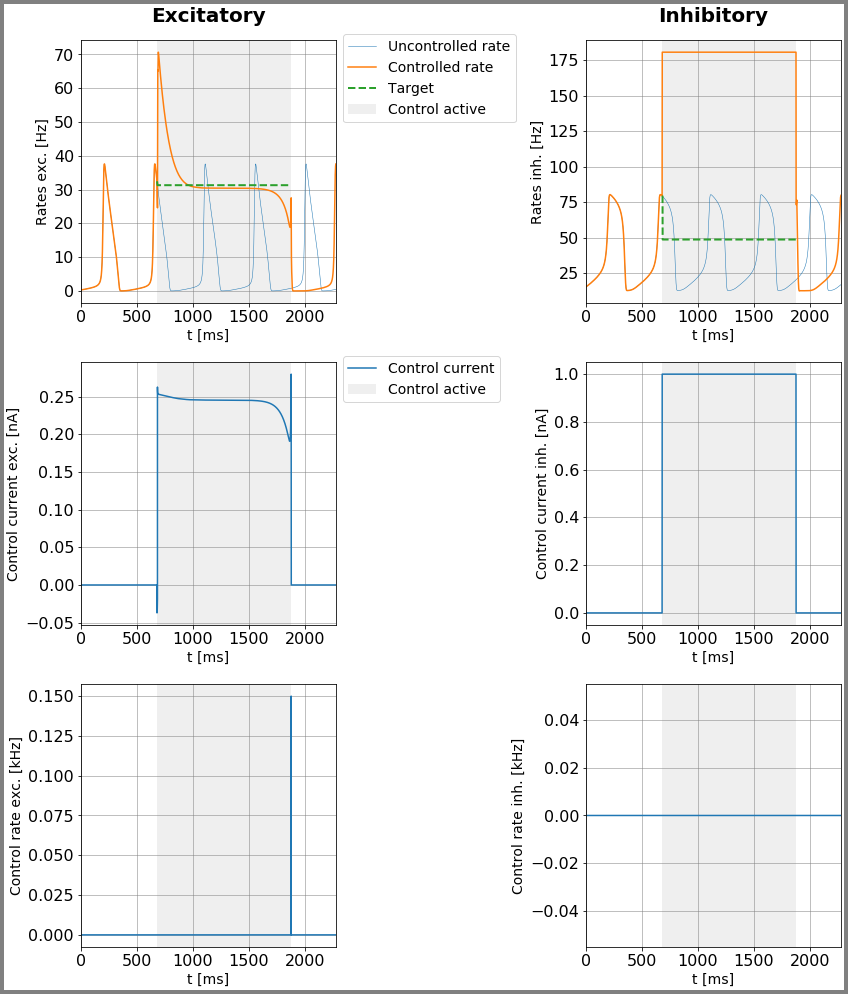

In [35]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = 1.4
#control0[0,1,:] = -1.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  111354.75736582407
adj inh rate = [3804.86361611 3729.2505325  3649.76280498 ...   -0.           -0.
   -0.        ]
adj mui = [54789.99820219 53442.54890884 52082.52406202 ...     0.
     0.             0.        ]
RUN  1 , total integrated cost =  71977.48590384201
adj inh rate = [809.36284529 787.89348764 765.9525615  ...  -0.          -0.
  -0.        ]
adj mui = [11362.90541133 11032.09536883 10706.89532257 ...     0.
     0.             0.        ]
RUN  2 , total integrated cost =  71977.48590384198
adj inh rate = [809.36284529 787.89348764 765.9525615  ...  -0.          -0.
  -0.        ]
adj mui = [11362.90541133 11032.09536883 10706.89532257 ...     0.
     0.             0.        ]


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  71977.48590384198
Control only changes marginally.
RUN  3 , total integrated cost =  71977.48590384198
Improved over  3  iterations by  35.36200194179345  percent.
Problem in initial value trasfer:  Vmean_exc -56.656362675176936 -56.656236357403934
Problem in initial value trasfer:  Vmean_exc -56.654565116736165 -56.65010488416464


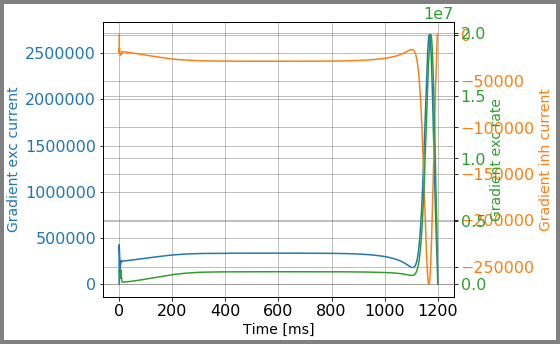

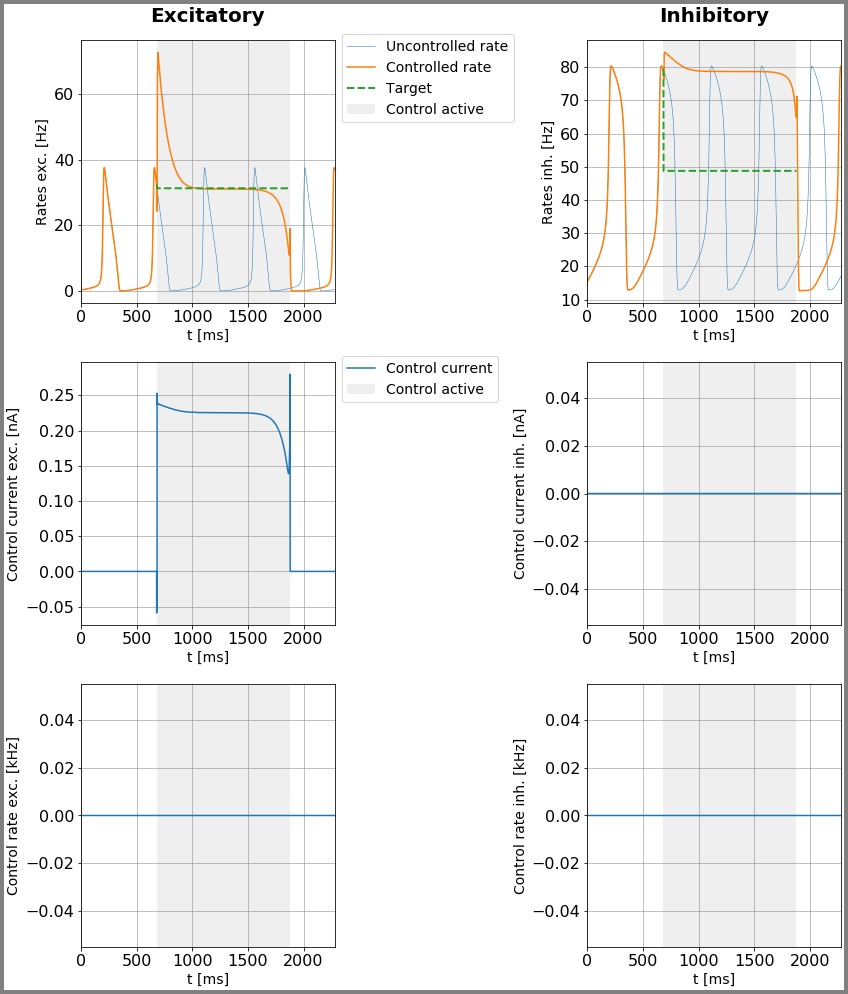

In [36]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = 1.4
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )